In [1]:
"""The main objective of this project on insurance data is to build a regression model that can accurately predict a target variable,
 such as the 'Premium Amount', based on various features in the dataset.
 The ultimate goal is to develop a model that can be used to predict insurance premiums or other relevant outcomes,
 which can help in decision-making processes, risk assessment, and pricing strategies in the insurance industry."""


#Importing required libraries
import jax
import jax.numpy as jnp
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Import sklearn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

#Import Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [2]:
data = pd.read_csv('train.csv')
data = data.dropna(subset=['Premium Amount']) # Removes rows where premium amount is missing values(NaN)
data.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [3]:
data.isnull().sum() # This gives the total count of missing values for each column in the DataFrame.

id                           0
Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Policy Start Date            0
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [4]:
data.drop('id', axis=1, inplace=True)
data.drop('Policy Start Date', axis=1, inplace=True)

In [5]:
#Seperating the features
NUMERICAL_COLUMNS = []
CATEGORICAL_COLUMNS = []

for name in data.columns:
    if data[name].dtype == 'object':
        CATEGORICAL_COLUMNS.append(name)
    else:
        NUMERICAL_COLUMNS.append(name)

NUMERICAL_COLUMNS.remove('Premium Amount')
FEATURES = NUMERICAL_COLUMNS + CATEGORICAL_COLUMNS
print('Features:', data.columns)
print('Numerical Columns:', NUMERICAL_COLUMNS)
print('Categorical Columns:', CATEGORICAL_COLUMNS)

Features: Index(['Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Customer Feedback',
       'Smoking Status', 'Exercise Frequency', 'Property Type',
       'Premium Amount'],
      dtype='object')
Numerical Columns: ['Age', 'Annual Income', 'Number of Dependents', 'Health Score', 'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration']
Categorical Columns: ['Gender', 'Marital Status', 'Education Level', 'Occupation', 'Location', 'Policy Type', 'Customer Feedback', 'Smoking Status', 'Exercise Frequency', 'Property Type']


In [6]:
# Converting categorical values to numerical values
le = LabelEncoder()
data_processed = data.copy()
for name in CATEGORICAL_COLUMNS:
    data_processed[name] = data_processed[name].fillna('missing') # For each categorical column, any missing values (NaN) are filled with the string 'missing'. This ensures that there are no missing values before encoding.
    data_processed[name] = le.fit_transform(data_processed[name])

In [7]:
data_processed

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,19.0,0,10049.0,1,1.0,0,1,22.598761,2,2,2.0,17.0,372.0,5.0,2,0,3,2,2869.0
1,39.0,0,31678.0,0,3.0,2,3,15.569731,0,1,1.0,12.0,694.0,2.0,0,1,1,2,1483.0
2,23.0,1,25602.0,0,3.0,1,1,47.177549,1,2,1.0,14.0,NaN,3.0,1,1,3,2,567.0
3,21.0,1,141855.0,1,2.0,0,3,10.938144,0,0,1.0,0.0,367.0,1.0,2,1,0,0,765.0
4,21.0,1,39651.0,2,1.0,0,1,20.376094,0,2,0.0,8.0,598.0,4.0,2,1,3,2,2022.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199995,36.0,0,27316.0,1,0.0,2,2,13.772907,2,2,NaN,5.0,372.0,3.0,2,0,0,0,1303.0
1199996,54.0,1,35786.0,0,NaN,2,1,11.483482,0,1,NaN,10.0,597.0,4.0,2,0,3,0,821.0
1199997,19.0,1,51884.0,0,0.0,2,3,14.724469,1,0,0.0,19.0,NaN,6.0,1,0,1,1,371.0
1199998,55.0,1,NaN,2,1.0,3,3,18.547381,1,2,1.0,7.0,407.0,4.0,2,0,0,0,596.0


In [8]:
#Creating a preprocessing pipeline
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), #The first step in the pipeline is an imputer. SimpleImputer from sklearn.impute is used to fill in missing values. The strategy='median' parameter specifies that missing values should be replaced with the median value of the column.
    ('scaler', StandardScaler()) # To standardize features by removing the mean and scaling to unit variance. This ensures that each feature contributes equally to the model.
])

In [9]:
preprocessor

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [10]:
X = data_processed.drop('Premium Amount', axis=1)
y = data_processed['Premium Amount']

In [11]:
X.head()

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
0,19.0,0,10049.0,1,1.0,0,1,22.598761,2,2,2.0,17.0,372.0,5.0,2,0,3,2
1,39.0,0,31678.0,0,3.0,2,3,15.569731,0,1,1.0,12.0,694.0,2.0,0,1,1,2
2,23.0,1,25602.0,0,3.0,1,1,47.177549,1,2,1.0,14.0,NaN,3.0,1,1,3,2
3,21.0,1,141855.0,1,2.0,0,3,10.938144,0,0,1.0,0.0,367.0,1.0,2,1,0,0
4,21.0,1,39651.0,2,1.0,0,1,20.376094,0,2,0.0,8.0,598.0,4.0,2,1,3,2


In [12]:
y.head()

0    2869.0
1    1483.0
2     567.0
3     765.0
4    2022.0
Name: Premium Amount, dtype: float64

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_processed_train = preprocessor.fit_transform(X_train)
X_processed_test = preprocessor.transform(X_test)

In [14]:
model = LinearRegression() # Instantiates a LinearRegression model.
model.fit(X_processed_train, y_train)
y_pred = model.predict(X_processed_test)

r2 = r2_score(y_test, y_pred) # Calculates the R-squared (coefficient of determination) score which quantifies the goodness of fit of the model. 
mse = mean_squared_error(y_test, y_pred) # Calculates the mean squared error which quantifies the average squared difference between the estimated values and the actual values.
mae = mean_absolute_error(y_test, y_pred) # Calculates the mean absolute error which quantifies the average absolute difference between the estimated values and the actual values.
print('R2 Score:', r2)
print('Mean Squared Error:', mse)
print('Mean Absolute Error:', mae)

R2 Score: 0.0029750551104371636
Mean Squared Error: 745062.3703224113
Mean Absolute Error: 667.1678904382617


In [15]:
model = Ridge() # Ridge regression is a linear regression model that uses L2 regularization. It adds a penalty term to the loss function which is proportional to the square of the magnitude of the coefficients. This helps to prevent overfitting by discouraging large coefficients.
model.fit(X_processed_train, y_train)
y_pred = model.predict(X_processed_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print('R2 Score:', r2)
print('Mean Squared Error:', mse)
print('Mean Absolute Error:', mae)

R2 Score: 0.0029750550630860406
Mean Squared Error: 745062.3703577961
Mean Absolute Error: 667.1678910759091


In [16]:
model = Lasso() # Lasso regression is a linear regression model that uses L1 regularization. It adds a penalty term to the loss function which is proportional to the absolute value of the coefficients. This helps to prevent overfitting by encouraging sparse solutions with many coefficients set to zero.
model.fit(X_processed_train, y_train)
y_pred = model.predict(X_processed_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print('R2 Score:', r2)
print('Mean Squared Error:', mse)
print('Mean Absolute Error:', mae)

R2 Score: 0.0029684405707178785
Mean Squared Error: 745067.3132726024
Mean Absolute Error: 667.1982435749027


In [17]:
#model = RandomForestRegressor(random_state=42) # Random Forest is an ensemble learning method that constructs a multitude of decision trees during training and outputs the average prediction of the individual trees for regression tasks.
#model = RandomForestRegressor(n_estimators=20,max_depth=10,random_state=42)
model = RandomForestRegressor(n_estimators=100,max_depth=10,random_state=42)
model.fit(X_processed_train, y_train)
y_pred = model.predict(X_processed_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print('R2 Score:', r2)
print('Mean Squared Error:', mse)
print('Mean Absolute Error:', mae)

R2 Score: 0.05709914792117132
Mean Squared Error: 704616.2159028922
Mean Absolute Error: 633.4820700993768


In [18]:
# #model = RandomForestRegressor(random_state=42) # Random Forest is an ensemble learning method that constructs a multitude of decision trees during training and outputs the average prediction of the individual trees for regression tasks.
# model = RandomForestRegressor(n_estimators=20,max_depth=10,max_features='sqrt',random_state=42)
# model.fit(X_processed_train, y_train)
# y_pred = model.predict(X_processed_test)

# r2 = r2_score(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# print('R2 Score:', r2)
# print('Mean Squared Error:', mse)
# print('Mean Absolute Error:', mae)

In [19]:

model = GradientBoostingRegressor(random_state=42) # Gradient Boosting is an ensemble learning method that builds a sequence of decision trees during training, where each tree corrects the errors of the previous tree. It outputs the sum of the predictions of the individual trees for regression tasks.
model.fit(X_processed_train, y_train)
y_pred = model.predict(X_processed_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print('R2 Score:', r2)
print('Mean Squared Error:', mse)
print('Mean Absolute Error:', mae)

R2 Score: 0.02818479211703695
Mean Squared Error: 726223.4972273932
Mean Absolute Error: 656.1536101288062


In [20]:
model = XGBRegressor(random_state=42) # XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It builds a sequence of decision trees during training, where each tree corrects the errors of the previous tree. It outputs the sum of the predictions of the individual trees for regression tasks.
model.fit(X_processed_train, y_train)
y_pred = model.predict(X_processed_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print('R2 Score:', r2)
print('Mean Squared Error:', mse)
print('Mean Absolute Error:', mae)

R2 Score: 0.050426191382400565
Mean Squared Error: 709602.8201411499
Mean Absolute Error: 639.5551802399317


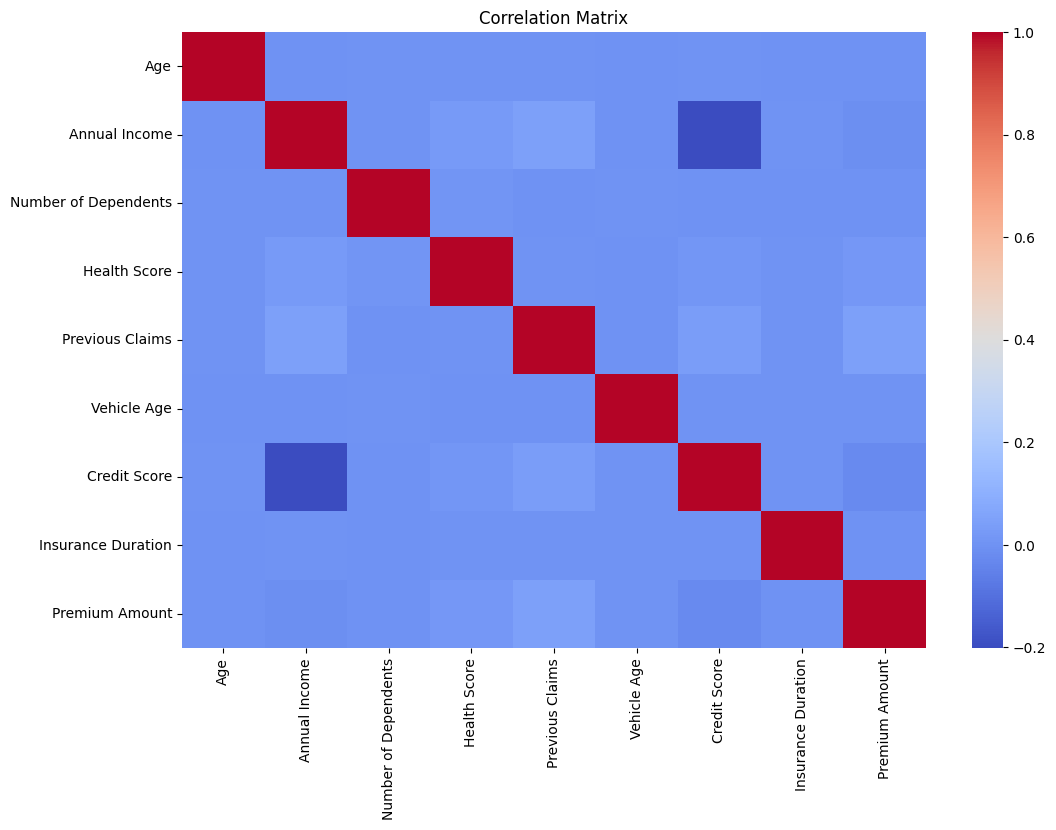

In [21]:
plt.figure(figsize=(12, 8))
correlation_matrix = data[NUMERICAL_COLUMNS + ['Premium Amount']].corr() # Calculates the correlation matrix between numerical columns and the target variable 'Premium Amount'.
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()